In [1]:
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 64
epochs = 10
lr = 1e-3
weights_dir = Path("../model_weights")
weights_dir.mkdir(parents=True, exist_ok=True)

In [3]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size)

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [5]:
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    print(f"epoch {epoch + 1}/{epochs} loss={total_loss / len(train_loader):.4f} acc={correct / total:.4f}")

epoch 1/10 loss=0.3482 acc=0.9466
epoch 2/10 loss=0.1482 acc=0.9641
epoch 3/10 loss=0.1018 acc=0.9674
epoch 4/10 loss=0.0754 acc=0.9734
epoch 5/10 loss=0.0591 acc=0.9744
epoch 6/10 loss=0.0463 acc=0.9763
epoch 7/10 loss=0.0384 acc=0.9708
epoch 8/10 loss=0.0323 acc=0.9777
epoch 9/10 loss=0.0261 acc=0.9778
epoch 10/10 loss=0.0211 acc=0.9749


In [6]:
torch.save(model.state_dict(), weights_dir / "mnist_mlp.pth")

Matplotlib is building the font cache; this may take a moment.


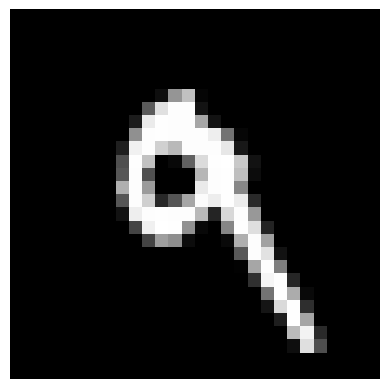

class: 9
confidence: 0.9999


In [8]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "../test_samples/digit_9.png"

model.eval()

image = Image.open(image_path).convert("L")
x = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    pred_class = probs.argmax(dim=1).item()
    confidence = probs[0, pred_class].item()

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

print("class:", pred_class)
print("confidence:", round(confidence, 4))